# USD SOFR 10s30s Flattener — desk pitch (steelman)

**One-line pitch.** Front end is a no-trade (guidance gone, distribution widened, SFR fly went directional — no edge). The one thing I'd put on is a **10s30s flattener**: it screens rich on the full **1y1y / 5y5y-breakeven / tariff / Fed-BS-%GDP** fair-value model (FRED-sourced, JPM's driver set), it's a **valuation + regime-convergence** trade (not a carry trade), and I chose 10s30s over 2s30s deliberately to keep it **clean of the front end I just said I won't trade**. It needs no directional call — it works on Warsh-credibility bull-flattening *and* on a front-led hawkish bear-flattening; the only thing that breaks it is a **30y-led term-premium / supply steepener**. Balance sheet is parked in a task force until the year-end review, so the ~3m window is clean.

All analytics use `RVUtils`: `regression` (fair value + beta-stability TLI), `carry_roll` (forwards + carry/roll), `screener_rv` (cross-structure rank), `pca_rv` (factor exposure), `seasonality_utils`.

In [1]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder
from RVUtils.plt_timeseries import make_secondary_axis_plot
from RVUtils.regression import make_linear_regression_builder, rolling_beta_stability, residual_diagnostics
from RVUtils.carry_roll import make_carry_roll_builder, forward_rate
from RVUtils.screener_rv import make_rv_screener
from RVUtils.pca_rv import make_pca_rv_builder
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=False), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}
TEN = ["1y", "2y", "3y", "5y", "7y", "10y", "20y", "30y"]
YRS = {"1y": 1, "2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
INV = {v: k for k, v in YRS.items()}
bp = 100.0
start = NYC.localize(datetime.datetime(2021, 1, 1, 17, 0))
end = NYC.localize(datetime.datetime(2026, 6, 17, 17, 0))
df = ts.get_timeseries(start=start, end=end,
    queries=[UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in TEN],
    n_jobs=8, routers=ROUTERS)
df = df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in TEN})[TEN]
df.index = pd.to_datetime(df.index)
curve_yrs = df.rename(columns=YRS)
r_1y1y = curve_yrs.apply(lambda row: forward_rate(row, 1, 1), axis=1)   # reds proxy (1y1y)
r_5y5y = curve_yrs.apply(lambda row: forward_rate(row, 5, 5), axis=1)   # 5y5y forward (nominal)
import urllib.request, io
def _fred(series, s="2021-01-01", e="2026-06-17"):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}&cosd={s}&coed={e}"
    raw = urllib.request.urlopen(url, timeout=30).read().decode()
    d = pd.read_csv(io.StringIO(raw)); d.columns = ["date", series]
    d["date"] = pd.to_datetime(d["date"]); d = d.set_index("date")
    return pd.to_numeric(d[series], errors="coerce").dropna()
be5y5y = _fred("T5YIFR").reindex(df.index).ffill()        # 5y5y fwd breakeven inflation, %
walcl  = _fred("WALCL").reindex(df.index).ffill()         # Fed total assets, $mn (weekly, ffilled)
gdp    = _fred("GDP").reindex(df.index).ffill()           # nominal GDP, $bn (quarterly, ffilled)
bs_gdp = walcl / (gdp * 1000.0) * 100.0                   # Fed balance sheet as % of GDP
print("Loaded", df.shape, df.index.min().date(), "->", df.index.max().date())
print(f"1y1y {r_1y1y.iloc[-1]:.2f}% | 5y5y_BE {be5y5y.iloc[-1]:.2f}% | Fed BS/GDP {bs_gdp.iloc[-1]:.1f}%")
df.tail(3)

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


Loaded (1365, 8) 2021-01-04 -> 2026-06-17
1y1y 3.94% | 5y5y_BE 2.21% | Fed BS/GDP 21.4%


,1y,2y,3y,5y,7y,10y,20y,30y
Date,,,,,,,,
2026-06-15,3.872651,3.922587,3.905793,3.912999,3.971968,4.075915,4.311921,4.273636
2026-06-16,3.866283,3.906366,3.884688,3.885388,3.943336,4.045849,4.281858,4.246070
2026-06-17,3.873761,3.905107,3.878312,3.876028,3.927737,4.029726,4.264042,4.224857


In [2]:
s10s30 = (df["30y"] - df["10y"]) * bp
s2s30 = (df["30y"] - df["2y"]) * bp
s2s10 = (df["10y"] - df["2y"]) * bp
print("10s30s:", round(s10s30.iloc[-1], 1), "bp  (range 2021+:", round(s10s30.min(),0), "to", round(s10s30.max(),0), ")")
print("2s30s :", round(s2s30.iloc[-1], 1), "bp")

10s30s: 19.5 bp  (range 2021+: -60.0 to 50.0 )
2s30s : 32.0 bp


## 1) Fair value — JPM's regressors, sourced from FRED
10s30s regressed on JPM's named drivers: **1y1y OIS** (from the SOFR curve), **5y5y forward breakeven** (FRED `T5YIFR`), and **Fed balance sheet as % of GDP** (FRED `WALCL`/`GDP`). Residual > 0 ⇒ steeper than fair ⇒ **rich to flatten**. (JPM's tariff dummy is omitted — a persistent regime dummy mostly just absorbs the recent level and isn't cleanly replicable.)

R2 0.872 | betas {'const': 147.41, '1y1y': -19.8, '5y5y_BE': 4.01, 'BS/GDP': -3.41}
current residual 14.4 bp (>0 => steep vs model) | rolling z252 0.86 | half-life 48.0 d | ADF p 0.148


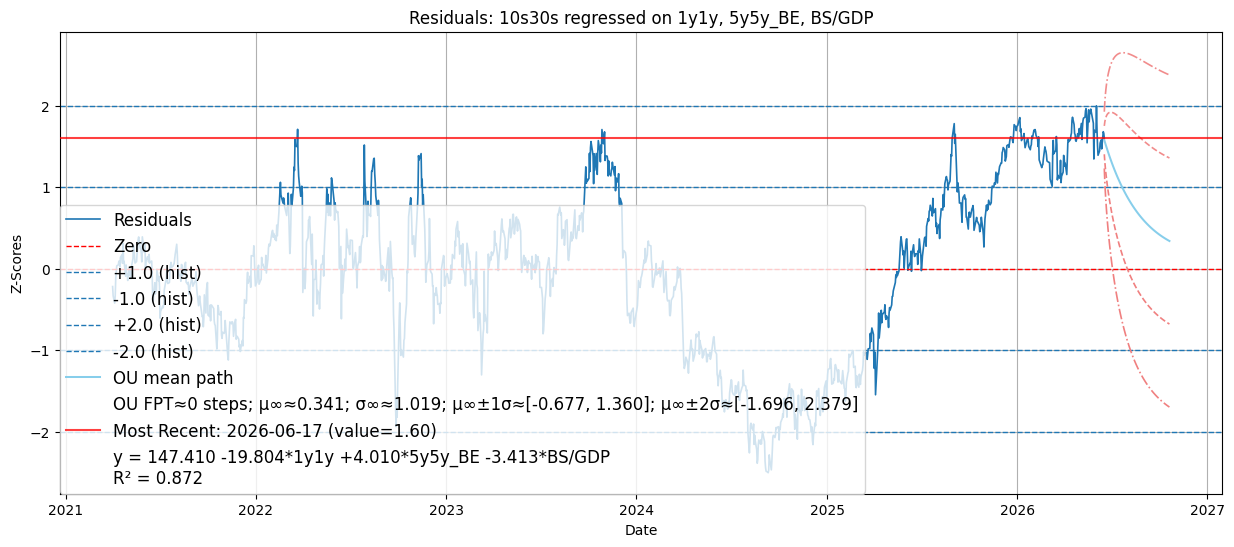

In [3]:
reg_df = pd.concat([s10s30.rename("10s30s"), r_1y1y.rename("1y1y"), be5y5y.rename("5y5y_BE"), bs_gdp.rename("BS/GDP")], axis=1).dropna()
add_indep_var, fitr, pavp, prvp, prts, getd = make_linear_regression_builder(df=reg_df, y_col="10s30s")
for d in ["1y1y", "5y5y_BE", "BS/GDP"]: add_indep_var(d)
res = fitr(model="OLS", verbose=False)
resid = res.resid
z = (resid - resid.rolling(252).mean()) / resid.rolling(252).std()
diag = residual_diagnostics(resid)
print("R2", round(res.rsquared, 3), "| betas", {k: round(float(v),2) for k,v in res.params.items()})
print("current residual", round(resid.iloc[-1], 1), "bp (>0 => steep vs model) | rolling z252", round(z.iloc[-1], 2), "| half-life", round(diag["half_life"],0), "d | ADF p", round(diag["adf_pvalue"], 3))
prts(plot_zscores=True, plot_zero=True, stds=[1, 2], ou_bands=True)

**Beta-stability (the live regime gauge).** A Warsh regime re-rating would destabilise the betas; TLI ≥ 3 = stand down.

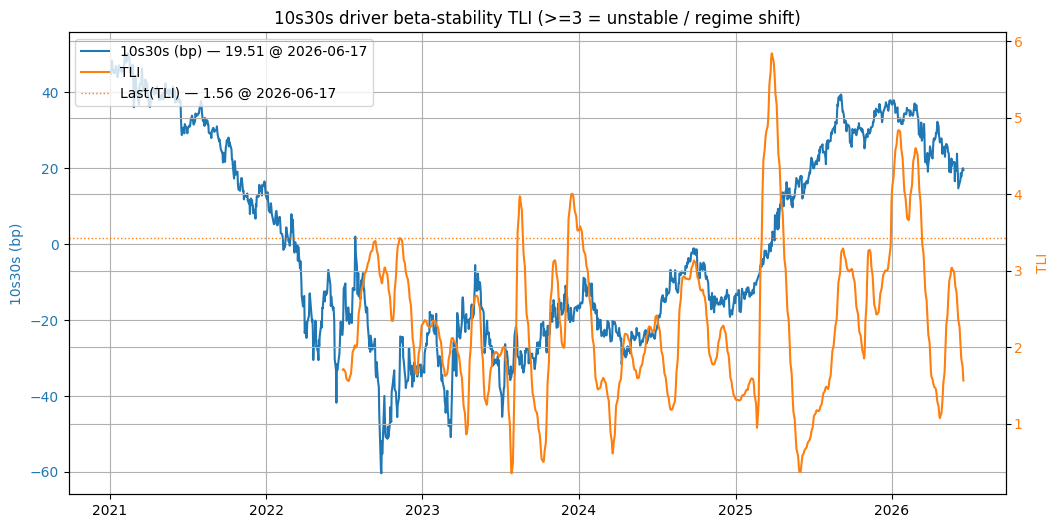

In [4]:
tli = rolling_beta_stability(s10s30, pd.concat([r_1y1y.rename("1y1y"), be5y5y.rename("5y5y_BE"), bs_gdp.rename("BS/GDP")], axis=1), window_beta=126, window_vol=63, window_z=126)
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="10s30s driver beta-stability TLI (>=3 = unstable / regime shift)")
plot(s10s30.rename("10s30s (bp)"), which="left")
plot(tli["TLI"].rename("TLI"), which="right", indicators=[{"kind": "last"}])
legend(show_date=True, loc="upper left"); plt.show()

## 2) Signal vs carry — this is a convergence trade; the carry is the cheap bleed
Carry+roll is **against** the flattener but small (negative = against). What matters is richness ÷ quarterly bleed.

In [5]:
roll_ts, carry_ts, total_ts, be_ts, ctv_ts, _ = make_carry_roll_builder(curve_yrs, horizon=0.25)
def flattener_cr(a, b): return total_ts(("curve", a, b)) * bp   # DV01-neutral a/b flattener carry+roll, bp/3m (<0 = against)
sig = abs(resid.iloc[-1])
c10 = flattener_cr(10, 30).iloc[-1]; c2 = flattener_cr(2, 30).iloc[-1]
print(f"10s30s: richness ~{sig:.1f}bp vs fair value | flattener carry+roll ~{c10:.2f}bp/q (<0 = against) | signal:carry ~{sig/abs(c10):.1f} : 1")
print(f"2s30s : flattener carry+roll ~{c2:.2f}bp/q (worse, and reintroduces the 2y).")
print("NB: this data-agnostic carry understates front-end carry; it ties out at the long end (10s30s ~-1.7bp = JPM table) but JPM shows 2s30s ~-5.7bp.")

10s30s: richness ~14.4bp vs fair value | flattener carry+roll ~-1.67bp/q (<0 = against) | signal:carry ~8.6 : 1
2s30s : flattener carry+roll ~-2.11bp/q (worse, and reintroduces the 2y).
NB: this data-agnostic carry understates front-end carry; it ties out at the long end (10s30s ~-1.7bp = JPM table) but JPM shows 2s30s ~-5.7bp.


## 3) PCA — a 10s30s flattener is mostly a slope (PC2) trade

In [6]:
bpca = make_pca_rv_builder(df, on="changes", n_factors=3, sort_by_tenor=False)
bpca[0]()
risk_buckets = bpca[6]
ladder = pd.Series(0.0, index=TEN); ladder["10y"] = 1.0; ladder["30y"] = -1.0   # DV01-neutral 10s30s flattener
exp = risk_buckets(ladder)
print("10s30s flattener PC exposures:", {k: round(float(v), 3) for k, v in exp.head(3).items()})

10s30s flattener PC exposures: {'PC1': 0.09, 'PC2': -0.21, 'PC3': -0.477}


## 4) Screen long-end flatteners (incl 2s30s): carry + beta to 10s30s
Candidates are spreads (steepener orientation, bp). `flat_carry_3m` is the **flattener** carry+roll (<0 = against); `beta_to_10s30s` (daily changes) confirms it moves with 10s30s. `level_z_own` is each spread's *own-history* z (mean-reversion lens) — distinct from the rich/cheap-vs-fair-value signal, which is the **regression residual in section 1**. Goal: improve the bleed while keeping 10s30s exposure, *without* re-adding the 2y.

In [7]:
cands = [(2,30),(3,30),(5,30),(7,30),(10,30),(10,20),(20,30),(7,20),(5,20)]
structs, betas = {}, {}
for a, b in cands:
    name = f"{a}s{b}s"
    sp = (df[INV[b]] - df[INV[a]]) * bp
    structs[name] = sp
    rd = pd.concat([sp.rename("sp"), s10s30.rename("x")], axis=1).dropna()
    aiv, fiv, _, _, _, _ = make_linear_regression_builder(df=rd, y_col="sp", on_diff=True)
    aiv("x"); rr = fiv(model="OLS"); betas[name] = float(rr.params["x"])
build, rank, to_df, di_fn, _ = make_rv_screener(pd.DataFrame(structs), zscore_window=252, vol_window=63, percentile_window=252, halflife_window=252)
tbl = to_df().copy().rename(columns={"zscore": "level_z_own"})
tbl["beta_to_10s30s"] = pd.Series(betas)
tbl["flat_carry_3m"] = pd.Series({f"{a}s{b}s": flattener_cr(a, b).iloc[-1] for a, b in cands})
tbl[["level","level_z_own","percentile","vol","flat_carry_3m","half_life","beta_to_10s30s"]].sort_values("flat_carry_3m", ascending=False).round(2)

,level,level_z_own,percentile,vol,flat_carry_3m,half_life,beta_to_10s30s
structure,,,,,,,
5s20s,38.80,-2.27,0.02,36.02,-0.07,27.47,1.29
7s20s,33.63,-2.09,0.03,27.51,-0.48,25.54,1.02
3s30s,34.65,-2.09,0.02,56.45,-0.49,25.54,1.81
10s20s,23.43,-1.90,0.04,17.91,-0.61,21.09,0.69
20s30s,-3.92,-0.76,0.23,21.43,-1.05,7.26,0.31
5s30s,34.88,-2.08,0.03,49.60,-1.13,21.38,1.61
7s30s,29.71,-1.87,0.04,42.29,-1.53,18.88,1.34
10s30s,19.51,-1.59,0.08,33.67,-1.67,15.44,1.00
2s30s,31.98,-1.76,0.03,57.28,-2.11,26.26,1.77


## 5) The pick — 10s30s is the clean expression; the screen quantifies the trade-off
All long-end flatteners carry against you (small). Among those with real 10s30s beta, 10s30s itself is the cleanest (beta 1.0, ~-1.7bp/q). Longer-dated (e.g. 20s30s) bleeds a touch less but barely tracks 10s30s; the 30y-enders carry worse and/or re-add the front end.

Clean expression = 10s30s | flattener carry+roll -1.67 bp/q | beta 1.0 | half-life 15.0 d
Best-carry alt (beta>0.6 to 10s30s): 5s20s -> carry -0.07 bp/q, beta 1.29


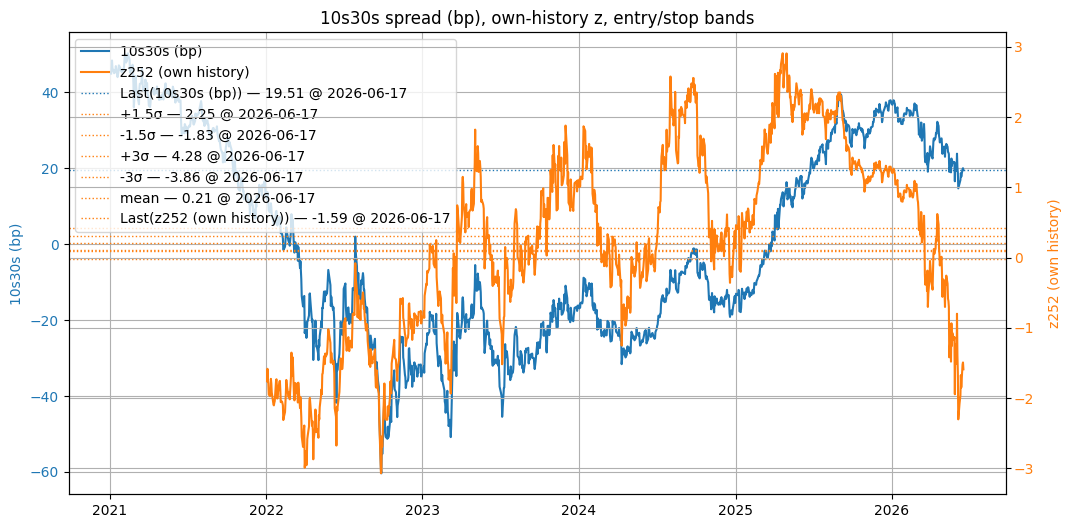

In [8]:
best_alt = tbl[tbl["beta_to_10s30s"] > 0.6].sort_values("flat_carry_3m", ascending=False)
print("Clean expression = 10s30s | flattener carry+roll", round(flattener_cr(10,30).iloc[-1],2), "bp/q | beta 1.0 | half-life", round(tbl.loc["10s30s","half_life"],0), "d")
print("Best-carry alt (beta>0.6 to 10s30s):", best_alt.index[0], "-> carry", round(best_alt.iloc[0]["flat_carry_3m"],2), "bp/q, beta", round(best_alt.iloc[0]["beta_to_10s30s"],2))
sp = s10s30
zsp = (sp - sp.rolling(252).mean()) / sp.rolling(252).std()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="10s30s spread (bp), own-history z, entry/stop bands")
plot(sp.rename("10s30s (bp)"), which="left", indicators=[{"kind": "last"}])
plot(zsp.rename("z252 (own history)"), which="right", indicators=[{"kind": "zbands", "entry": 1.5, "stop": 3}, {"kind": "last"}])
legend(show_date=True, loc="upper left"); plt.show()

## 6) Seasonality — *context only* (small N); the real driver is the credibility mechanism
The 'curve flattens into a new chair' leg is weak as an n≈5 seasonal and the first-meeting 2y selloff (~6bp, Citi) is already realised (6/17). The durable mechanism is: a credibly hawkish chair compresses **long-end inflation premium** → flatten. Charts below for completeness (use `seasonality_utils`).

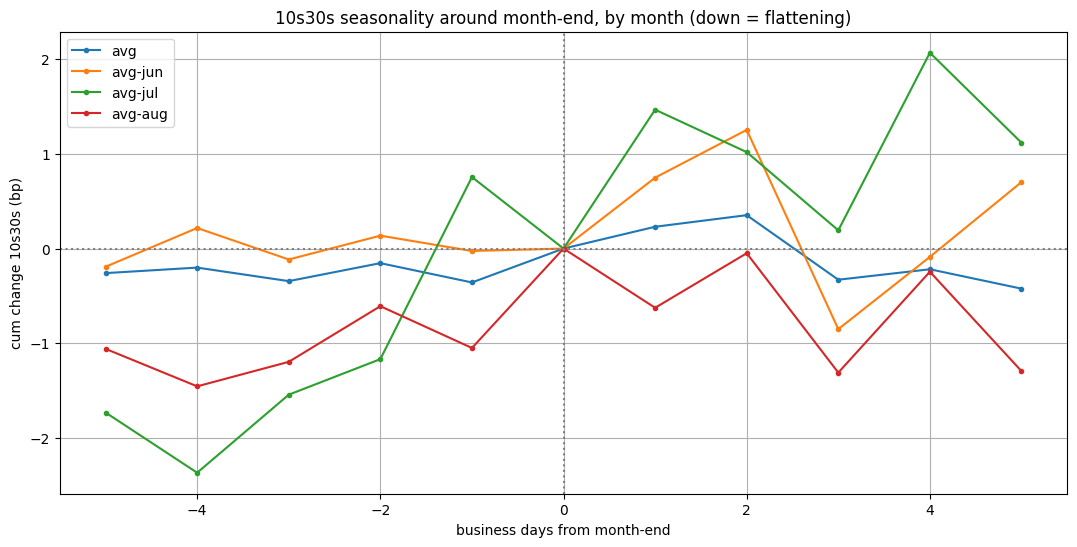

In [9]:
seas = monthend_cumsum_seasonality(s10s30.to_frame("10s30s"), value_col="10s30s", window=5, metric="abs")
fig, axx = plt.subplots(figsize=(13, 6))
for col in ["avg", "avg-jun", "avg-jul", "avg-aug"]:
    if col in seas.columns: axx.plot(seas.index, seas[col], marker=".", label=col)
axx.axvline(0, color="grey", ls=":"); axx.axhline(0, color="grey", ls=":")
axx.set_xlabel("business days from month-end"); axx.set_ylabel("cum change 10s30s (bp)")
axx.set_title("10s30s seasonality around month-end, by month (down = flattening)"); axx.legend(); plt.show()

In [10]:
mc = s10s30.resample("ME").last().diff()
by_month = mc.groupby(mc.index.month).agg(["mean", "median", "count"])
by_month.index = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
print("Avg month-over-month change in 10s30s by calendar month (bp; negative = flattening):")
by_month.round(1)

Avg month-over-month change in 10s30s by calendar month (bp; negative = flattening):


,mean,median,count
jan,2.5,4.0,5
feb,-5.7,-6.3,6
mar,-0.1,2.3,6
apr,-0.4,-0.7,6
may,3.0,1.9,6
jun,-5.2,-4.7,6
jul,7.4,6.0,5
aug,-0.1,4.3,5
sep,-7.3,-4.5,5
oct,-0.9,-0.3,5


## 7) Getting to POSITIVE carry: forward-starting & PCA-weighted structures
Spot flattener bleeds ~1.7bp/q. Two levers keep 10s30s exposure while flipping/cutting carry: **(a) forward-start** (roll down the forward 10s30s term structure) and **(b) PCA PC1-neutral weighting** (strip the level leg that drags carry). Forward curves use constant end-maturities (10y/30y buckets, S-forward) so they stay within the 30y data.

In [11]:
from RVUtils.carry_roll import roll_down, carry as carry_fn
def fwd_flat(S, a, b):
    return curve_yrs.apply(lambda r: forward_rate(r, S, b - S) - forward_rate(r, S, a - S), axis=1) * bp
def beta1030(sp):
    rd = pd.concat([sp.rename("sp"), s10s30.rename("x")], axis=1).dropna()
    aiv, fiv, _, _, _, _ = make_linear_regression_builder(df=rd, y_col="sp", on_diff=True); aiv("x")
    return float(fiv(model="OLS").params["x"])
rows = []
for a, b, lab in [(10,30,"10s30s"),(10,20,"10s20s"),(7,30,"7s30s"),(5,30,"5s30s")]:
    for S in [0.0, 0.5, 1.0, 2.0]:
        sp = fwd_flat(S, a, b); spm = fwd_flat(max(S-0.25, 0.0), a, b)
        z = (sp.iloc[-1] - sp.rolling(252).mean().iloc[-1]) / sp.rolling(252).std().iloc[-1]
        rows.append({"struct": f"{S:g}y fwd {lab}", "level_bp": round(sp.iloc[-1],1), "carry_roll_3m": round(float(sp.iloc[-1]-spm.iloc[-1]),2), "beta_to_10s30s": round(beta1030(sp),2), "z252": round(float(z),2)})
print("Forward flatteners (constant end-maturity); carry_roll_3m > 0 = POSITIVE carry:")
pd.DataFrame(rows).sort_values("carry_roll_3m", ascending=False).round(2)

Forward flatteners (constant end-maturity); carry_roll_3m > 0 = POSITIVE carry:


,struct,level_bp,carry_roll_3m,beta_to_10s30s,z252
14,1y fwd 5s30s,36.0,0.71,1.74,-2.21
15,2y fwd 5s30s,39.1,0.62,1.63,-2.07
10,1y fwd 7s30s,30.0,0.32,1.39,-1.99
6,1y fwd 10s20s,23.8,0.18,0.71,-1.99
13,0.5y fwd 5s30s,34.8,0.18,1.72,-2.21
11,2y fwd 7s30s,31.1,0.12,1.29,-1.77
7,2y fwd 10s20s,24.3,0.06,0.66,-1.76
5,0.5y fwd 10s20s,23.4,0.06,0.71,-2.01
9,0.5y fwd 7s30s,29.5,0.02,1.40,-2.00
0,0y fwd 10s30s,19.5,0.00,1.00,-1.59


In [12]:
bpx = make_pca_rv_builder(curve_yrs, on="changes", n_factors=3, sort_by_tenor=False); bpx[0]()
curvew = bpx[4]
def flat_cr_w(legs_w, h=0.25):
    last = curve_yrs.iloc[-1]
    return sum(w * (roll_down(last, t, h) + carry_fn(last, t, h)) for t, w in legs_w) * bp
def fwd_flat_w(S, short, long, ws, wl):
    return curve_yrs.apply(lambda r: wl*forward_rate(r, S, long-S) + ws*forward_rate(r, S, short-S), axis=1) * bp
res = []
for short, long, lab in [(10,30,"10s30s"),(5,30,"5s30s")]:
    w = curvew(short, long, neutralize=("PC1",)); ws, wl = w[short], w[long]
    sp = (wl*curve_yrs[long] + ws*curve_yrs[short]) * bp
    res.append({"struct": f"{lab} PC1-neutral (spot)", "weights": f"{wl:.2f}:{ws:.2f}", "carry_roll_3m": round(flat_cr_w([(long,wl),(short,ws)]),2), "beta_to_10s30s": round(beta1030(sp),2)})
    spf = fwd_flat_w(1.0, short, long, ws, wl); spfm = fwd_flat_w(0.75, short, long, ws, wl)
    res.append({"struct": f"{lab} PC1-neutral (1y fwd)", "weights": f"{wl:.2f}:{ws:.2f}", "carry_roll_3m": round(float(spf.iloc[-1]-spfm.iloc[-1]),2), "beta_to_10s30s": round(beta1030(spf),2)})
print("PC1-neutral (level-neutral) cuts the drag; forward-start flips it positive:")
pd.DataFrame(res).round(2)

PC1-neutral (level-neutral) cuts the drag; forward-start flips it positive:


,struct,weights,carry_roll_3m,beta_to_10s30s
0,10s30s PC1-neutral (spot),1.00:-0.75,-1.28,0.67
1,10s30s PC1-neutral (1y fwd),1.00:-0.75,0.06,0.69
2,5s30s PC1-neutral (spot),1.00:-0.68,-0.80,0.98
3,5s30s PC1-neutral (1y fwd),1.00:-0.68,0.56,1.08


RECOMMENDATION: 1y-fwd 5s30s flattener | carry+roll +0.71bp/q (POSITIVE) | beta 1.74 to 10s30s | size ~0.57x DV01 to match 10s30s risk
  LEGS: RECEIVE 30y, PAY 5y (1y forward). spread = 30y - 5y; flattener profits if it FALLS; carry_roll>0 accrues to the flattener.
  sizing: DV01-neutral 1:1, or PC1-neutral 1:0.68 (receive 1.0 DV01 30y / pay 0.68 DV01 5y); convert to notional via per-tenor DV01 in your pricer.


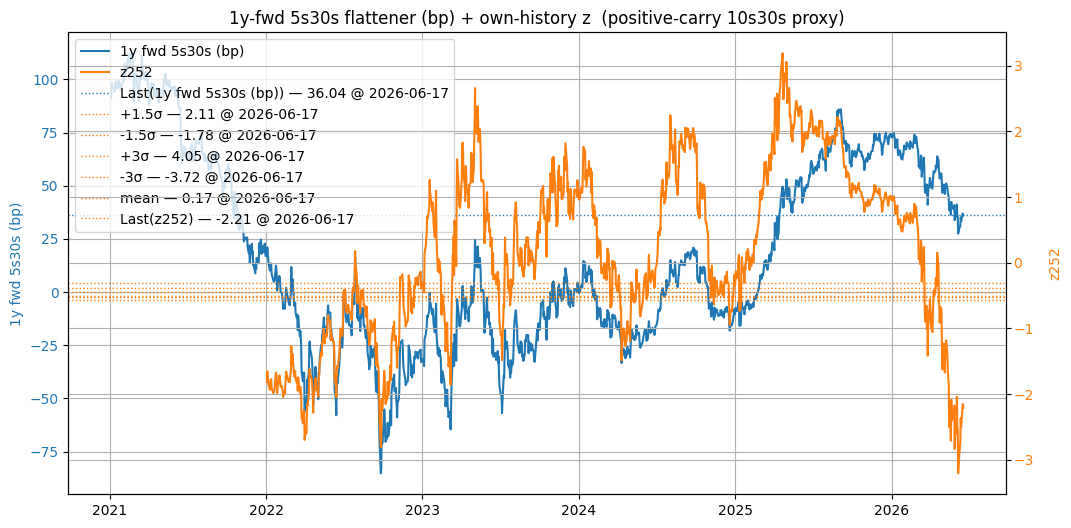

In [13]:
rec = fwd_flat(1.0, 5, 30)
cr_rec = float(rec.iloc[-1] - fwd_flat(0.75, 5, 30).iloc[-1]); b_rec = beta1030(rec)
print(f"RECOMMENDATION: 1y-fwd 5s30s flattener | carry+roll +{cr_rec:.2f}bp/q (POSITIVE) | beta {b_rec:.2f} to 10s30s | size ~{1/b_rec:.2f}x DV01 to match 10s30s risk")
print("  LEGS: RECEIVE 30y, PAY 5y (1y forward). spread = 30y - 5y; flattener profits if it FALLS; carry_roll>0 accrues to the flattener.")
print("  sizing: DV01-neutral 1:1, or PC1-neutral 1:0.68 (receive 1.0 DV01 30y / pay 0.68 DV01 5y); convert to notional via per-tenor DV01 in your pricer.")
zrec = (rec - rec.rolling(252).mean()) / rec.rolling(252).std()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="1y-fwd 5s30s flattener (bp) + own-history z  (positive-carry 10s30s proxy)")
plot(rec.rename("1y fwd 5s30s (bp)"), which="left", indicators=[{"kind": "last"}])
plot(zrec.rename("z252"), which="right", indicators=[{"kind": "zbands", "entry": 1.5, "stop": 3}, {"kind": "last"}])
legend(show_date=True, loc="upper left"); plt.show()

**Convention:** flattener = **receive 30y, pay 5y**; spread = 30y − 5y; the trade profits when the spread **falls**, and `carry_roll_3m > 0` accrues *to the flattener*.

**Recommended positive-carry expression: 1y-forward 5s30s flattener** (constant 5y/30y maturities, 1y forward; receive 30y / pay 5y) — **+~0.7 bp/q** carry+roll vs **−1.7 bp/q** spot 10s30s, **beta ~1.7 to 10s30s** (size to ~0.6× DV01 to match 10s30s risk). It carries because the forward 5s30s spread rolls down an upward-in-start term structure, and 5s30s captures more belly→long roll than 10s30s. **For a level-clean version**, apply **PC1-neutral weights** (≈ 1 : −0.68) to strip the directional leg. Caveats: 5s30s re-adds the 5y **belly** (not the 2y front-end — still consistent with the front-end pass) and runs ~1.7× the 10s30s beta (size down); the forward carry is the static-curve term-structure slide and decays if the curve re-steepens.

## Takeaways for the desk
- **Front end = no trade, and lead with it.** Guidance gone, statement shortest in decades, 2026 median dot up to 3.8%, ~half the Committee penciling hikes, FedWatch ~60% Oct hike, SFR fly directional. No edge → don't force it. That selectivity is *why* the one trade I do pitch is credible.
- **The trade = 10s30s flattener as a valuation+regime convergence trade**, not a carry trade. On JPM's named drivers (1y1y / 5y5y-BE / Fed-BS/%GDP, FRED-sourced) the model fits R² ~0.9 and screens 10s30s rich (residual in §1), corroborating the direction of JPM's ~14bp screen. Carry is ~1.7bp/q against — cheap relative to the convergence. (Summer-carry rationale dropped.)
- **Why 10s30s not 2s30s:** similar standardized richness, but 2s30s carries worse and re-adds the 2y front-end I have no edge in. The front-end discipline *is* the reason for the expression.
- **No directional call needed:** wins on Warsh-credibility bull-flatten or a front-led hawkish bear-flatten. **Single underwrite = the next shock is not a 30y-led term-premium/supply cheapening.** That is also the squeeze risk if the flattener is crowded.
- **Calendar:** balance sheet parked to year-end task force (3m window clean). Real dates: **Aug 5 QRA** (if they pull 'at least', expect a steepening knee-jerk = stop test) and the **30y auctions (~Jul 9, ~Aug 13)** as the demand tell on the leg you're long (June 30y was soft; June 20y stopped 1bp through). Supply *quantity* is regular cadence, already in forwards; 20s/30s sizes frozen.
- **Pre-empt 'it's the house trade / crowded':** that's valuation corroboration, but check CFTC / desk flow — if flattener positioning is one-sided, the pain trade is exactly the 30y-led steepener. Size as value-convergence, not conviction macro.
- **Risk monitors:** beta-stability TLI (regime), realized CPI/PCE (4.2%/3.8% — credibility asserted, not yet in data; if inflation doesn't cooperate the bull-flatten channel flips to a term-premium steepener = stop), and the 30y auction tone.